In [1]:
# =========================
# KOMÓRKA 0: BALANSOWANIE ZBIORÓW TRAIN I TEST WG KLASY WIEKU
# =========================
# Komórka:
# 1. wczytuje validated_train.csv i validated_test.csv
# 2. sprawdza, dla których rekordów istnieje spektrogram .npy
# 3. sprawdza najmniej liczną klasę age_cat
# 4. z każdej klasy losuje tyle samo rekordów
# 5. zapisuje nowe zbalansowane pliki CSV
#
# Po tej komórce reszta notebooka może korzystać z:
# balanced_validated_train.csv
# balanced_validated_test.csv

import pandas as pd
import numpy as np
import os
from pathlib import Path
from IPython.display import display

RANDOM_STATE = 42

SOURCE_TRAIN_CSV = "validated_train.csv"
SOURCE_TEST_CSV = "validated_test.csv"

TRAIN_SPEC_DIR = "validated_train/spectrograms"
TEST_SPEC_DIR = "validated_test/spectrograms"

BALANCED_TRAIN_CSV = "balanced_validated_train.csv"
BALANCED_TEST_CSV = "balanced_validated_test.csv"


def add_spectrogram_path(df, spec_dir):
    df = df.copy()

    # Z pliku .mp3 robimy nazwę .npy
    # np. common_voice_pl_20685868.mp3 -> common_voice_pl_20685868.npy
    df["npy_name"] = df["path"].apply(
        lambda x: Path(str(x)).with_suffix(".npy").name
    )

    df["spec_path"] = df["npy_name"].apply(
        lambda name: os.path.join(spec_dir, name)
    )

    df["has_spectrogram"] = df["spec_path"].apply(os.path.exists)

    return df


def balance_dataset_by_class(csv_path, spec_dir, output_csv):
    print("=" * 80)
    print(f"Przetwarzanie: {csv_path}")

    df = pd.read_csv(csv_path)

    # Usunięcie ewentualnych spacji z nazw kolumn
    df.columns = df.columns.str.strip()

    required_columns = ["path", "age", "gender", "age_cat"]
    missing_columns = [col for col in required_columns if col not in df.columns]

    if missing_columns:
        raise ValueError(f"W pliku {csv_path} brakuje kolumn: {missing_columns}")

    df = df.copy()
    df["age_cat"] = pd.to_numeric(df["age_cat"], errors="coerce")

    # Usunięcie rekordów bez klasy wieku
    before_age_filter = len(df)
    df = df[df["age_cat"].notna()].copy()
    df["age_cat"] = df["age_cat"].astype(int)

    print(f"Liczba rekordów w CSV: {before_age_filter}")
    print(f"Po usunięciu rekordów bez age_cat: {len(df)}")

    # Sprawdzenie istnienia spektrogramów
    df = add_spectrogram_path(df, spec_dir)

    print(f"Liczba rekordów z istniejącym spektrogramem .npy: {df['has_spectrogram'].sum()}")
    print(f"Liczba rekordów bez spektrogramu .npy: {(~df['has_spectrogram']).sum()}")

    df_valid = df[df["has_spectrogram"]].copy()

    if len(df_valid) == 0:
        raise ValueError(
            f"Nie znaleziono żadnych pasujących spektrogramów .npy dla pliku {csv_path}. "
            f"Sprawdź TRAIN_SPEC_DIR / TEST_SPEC_DIR."
        )

    print("\nLiczebność klas przed balansowaniem:")
    class_counts_before = (
        df_valid
        .groupby(["age_cat", "age"])
        .size()
        .reset_index(name="liczba")
        .sort_values("age_cat")
    )
    display(class_counts_before)

    # Liczebność każdej klasy
    class_counts = df_valid["age_cat"].value_counts().sort_index()

    print("\nLiczebność klas age_cat:")
    display(class_counts)

    # Najmniej liczna klasa
    min_class_count = class_counts.min()

    print(f"Najmniej reprezentowana klasa ma: {min_class_count} próbek")
    print(f"Z każdej klasy zostanie wybrane po: {min_class_count} próbek")

    # Stabilniejsze balansowanie bez groupby().apply()
    balanced_parts = []

    for class_id in sorted(df_valid["age_cat"].unique()):
        class_subset = df_valid[df_valid["age_cat"] == class_id].copy()

        sampled_subset = class_subset.sample(
            n=min_class_count,
            random_state=RANDOM_STATE
        )

        balanced_parts.append(sampled_subset)

    balanced_df = pd.concat(balanced_parts, ignore_index=True)

    # Losowe przemieszanie po złączeniu klas
    balanced_df = balanced_df.sample(
        frac=1,
        random_state=RANDOM_STATE
    ).reset_index(drop=True)

    print("\nLiczebność klas po balansowaniu:")
    class_counts_after = (
        balanced_df
        .groupby(["age_cat", "age"])
        .size()
        .reset_index(name="liczba")
        .sort_values("age_cat")
    )
    display(class_counts_after)

    # Do CSV zapisujemy tylko oryginalne kolumny, żeby reszta notebooka działała bez zmian
    balanced_df_to_save = balanced_df[["path", "age", "gender", "age_cat"]].copy()

    balanced_df_to_save.to_csv(output_csv, index=False)

    print(f"\nZapisano zbalansowany plik: {output_csv}")
    print(f"Liczba rekordów po balansowaniu: {len(balanced_df_to_save)}")

    return balanced_df_to_save

balanced_train = balance_dataset_by_class(
    csv_path=SOURCE_TRAIN_CSV,
    spec_dir=TRAIN_SPEC_DIR,
    output_csv=BALANCED_TRAIN_CSV
)

balanced_test = balance_dataset_by_class(
    csv_path=SOURCE_TEST_CSV,
    spec_dir=TEST_SPEC_DIR,
    output_csv=BALANCED_TEST_CSV
)

# Te zmienne ustawiamy tak, żeby dalsze komórki mogły korzystać ze zbalansowanych CSV.
TRAIN_CSV = BALANCED_TRAIN_CSV
TEST_CSV = BALANCED_TEST_CSV

print("=" * 80)
print("Gotowe.")
print(f"TRAIN_CSV = {TRAIN_CSV}")
print(f"TEST_CSV = {TEST_CSV}")

Przetwarzanie: validated_train.csv
Liczba rekordów w CSV: 70699
Po usunięciu rekordów bez age_cat: 70699
Liczba rekordów z istniejącym spektrogramem .npy: 70699
Liczba rekordów bez spektrogramu .npy: 0

Liczebność klas przed balansowaniem:


,age_cat,age,liczba
0,0,teens,1921
1,0,twenties,25825
2,1,fourties,10482
3,1,thirties,31399
4,2,fifties,516
5,2,nineties,517
6,2,seventies,2
7,2,sixties,37



Liczebność klas age_cat:


age_cat
0    27746
1    41881
2     1072
Name: count, dtype: int64

Najmniej reprezentowana klasa ma: 1072 próbek
Z każdej klasy zostanie wybrane po: 1072 próbek

Liczebność klas po balansowaniu:


...


Liczebność klas age_cat:


age_cat
0    11892
1    17949
2      460
Name: count, dtype: int64

Najmniej reprezentowana klasa ma: 460 próbek
Z każdej klasy zostanie wybrane po: 460 próbek

Liczebność klas po balansowaniu:


,age_cat,age,liczba
0,0,teens,30
1,0,twenties,430
2,1,fourties,117
3,1,thirties,343
4,2,fifties,215
5,2,nineties,227
6,2,seventies,2
7,2,sixties,16



Zapisano zbalansowany plik: balanced_validated_test.csv
Liczba rekordów po balansowaniu: 1380
Gotowe.
TRAIN_CSV = balanced_validated_train.csv
TEST_CSV = balanced_validated_test.csv


In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm

# =========================
# KONFIGURACJA
# =========================
TRAIN_CSV = "balanced_validated_train.csv"
TRAIN_SPEC_DIR = "validated_train/spectrograms"
MODEL_PATH = "age_classifier_no_gender_best_balanced.pth"
HISTORY_CSV = "training_history.csv"

EPOCHS = 40
BATCH_SIZE = 32
LR = 0.001
WEIGHT_DECAY = 1e-4
VAL_SPLIT = 0.10
SEED=42


def spectrogram_path_from_mp3_name(spec_dir, mp3_path):
    """
    Z CSV bierzemy np. common_voice_pl_20685868.mp3,
    a na dysku szukamy train/common_voice_pl_20685868.npy.
    """
    npy_name = Path(str(mp3_path)).with_suffix(".npy").name
    return os.path.join(spec_dir, npy_name)


def make_class_to_age_map(*csv_paths):
    """
    Tworzy mapowanie np. 0 -> twenties, 1 -> sixties itd.
    Używane tylko do czytelnego opisu wyników, model dalej uczy się klas liczbowych.
    """
    frames = []
    for csv_path in csv_paths:
        if os.path.exists(csv_path):
            frames.append(pd.read_csv(csv_path))

    if not frames:
        return {}

    df = pd.concat(frames, ignore_index=True)
    df = df[df["age_cat"].notna() & df["age"].notna()].copy()
    df["age_cat"] = df["age_cat"].astype(int)

    mapping = {}
    for class_id, group in df.groupby("age_cat"):
        mapping[int(class_id)] = group["age"].mode().iloc[0]

    return mapping


class AudioAgeDataset(Dataset):
    def __init__(self, csv_file, spec_dir, return_info=False):
        self.csv_file = csv_file
        self.spec_dir = spec_dir
        self.return_info = return_info

        self.df = pd.read_csv(csv_file)
        self.df = self.df[self.df["age_cat"].notna()].copy()
        self.df["age_cat"] = self.df["age_cat"].astype(int)

        self.df["spec_path"] = self.df["path"].apply(
            lambda p: spectrogram_path_from_mp3_name(self.spec_dir, p)
        )

        before = len(self.df)
        self.df = self.df[self.df["spec_path"].apply(os.path.exists)].reset_index(drop=True)
        missing = before - len(self.df)

        print(f"Wczytano {len(self.df)} poprawnych próbek z {csv_file}")
        if missing > 0:
            print(f"Pominięto {missing} próbek, bo nie znaleziono odpowiadających plików .npy")

        if len(self.df) == 0:
            raise RuntimeError(
                f"Brak próbek po sprawdzeniu plików .npy. Sprawdź csv_file={csv_file} oraz spec_dir={spec_dir}"
            )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        mel_db = np.load(row["spec_path"])
        mel_tensor = torch.from_numpy(mel_db).unsqueeze(0).float()  # [1, n_mels, czas]
        label = int(row["age_cat"])

        if self.return_info:
            return mel_tensor, label, str(row["path"]), str(row.get("age", ""))

        return mel_tensor, label


def pad_collate(batch):
    """
    Pozwala ładować batch nawet wtedy, gdy spektrogramy mają różną długość w osi czasu.
    Jeśli wszystkie spektrogramy mają identyczny rozmiar, ta funkcja też działa normalnie.
    """
    has_info = len(batch[0]) == 4

    if has_info:
        tensors, labels, paths, ages = zip(*batch)
    else:
        tensors, labels = zip(*batch)

    max_h = max(t.shape[1] for t in tensors)
    max_w = max(t.shape[2] for t in tensors)

    padded = []
    for t in tensors:
        pad_h = max_h - t.shape[1]
        pad_w = max_w - t.shape[2]
        padded.append(F.pad(t, (0, pad_w, 0, pad_h)))

    inputs = torch.stack(padded)
    labels = torch.tensor(labels, dtype=torch.long)

    if has_info:
        return inputs, labels, list(paths), list(ages)

    return inputs, labels


class AgeClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super(AgeClassifier, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4))
        )

        # Bez +1, bo nie dokładamy już wektora płci.
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, start_dim=1)
        return self.fc_layers(x)


def train_model():
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Używane urządzenie: {device}")

    full_dataset = AudioAgeDataset(TRAIN_CSV, TRAIN_SPEC_DIR)

    num_classes = int(full_dataset.df["age_cat"].max()) + 1
    class_to_age = make_class_to_age_map(TRAIN_CSV)
    print(f"Liczba klas: {num_classes}")
    print(f"Mapowanie klas: {class_to_age}")

    val_size = int(VAL_SPLIT * len(full_dataset))
    train_size = len(full_dataset) - val_size

    generator = torch.Generator().manual_seed(SEED)
    train_dataset, val_dataset = random_split(
        full_dataset,
        [train_size, val_size],
        generator=generator
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=pad_collate
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=pad_collate
    )

    model = AgeClassifier(num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    best_val_loss = float("inf")
    history = []

    for epoch in range(EPOCHS):
        model.train()
        running_train_loss = 0.0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS} [TRAIN]")
        for inputs, labels in train_bar:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            train_bar.set_postfix({"train_loss": f"{loss.item():.4f}"})

        avg_train_loss = running_train_loss / len(train_loader)

        model.eval()
        running_val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

        avg_val_loss = running_val_loss / len(val_loader)
        val_acc = 100.0 * val_correct / val_total

        row = {
            "epoch": epoch + 1,
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_accuracy": val_acc
        }
        history.append(row)
        pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

        print(
            f"Epoch {epoch + 1}: "
            f"Train Loss={avg_train_loss:.4f} | "
            f"Val Loss={avg_val_loss:.4f} | "
            f"Val Acc={val_acc:.2f}%"
        )

        scheduler.step()

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "num_classes": num_classes,
                    "class_to_age": class_to_age,
                    "history": history,
                },
                MODEL_PATH
            )
            print(f"--> Zapisano najlepszy model: {MODEL_PATH}, Val Loss={best_val_loss:.4f}")

    return model, pd.DataFrame(history), class_to_age


model, history_df, class_to_age = train_model()
print("Trening zakończony.")
print(history_df.tail())


Używane urządzenie: cuda
Wczytano 3216 poprawnych próbek z balanced_validated_train.csv
Liczba klas: 3
Mapowanie klas: {0: 'twenties', 1: 'thirties', 2: 'nineties'}


Epoch 1/40 [TRAIN]: 100%|██████████| 91/91 [00:01<00:00, 71.93it/s, train_loss=0.5662]


Epoch 1: Train Loss=0.9304 | Val Loss=0.7257 | Val Acc=64.49%
--> Zapisano najlepszy model: age_classifier_no_gender_best_balanced.pth, Val Loss=0.7257


Epoch 2/40 [TRAIN]: 100%|██████████| 91/91 [00:01<00:00, 89.93it/s, train_loss=0.4718]


Epoch 2: Train Loss=0.6442 | Val Loss=2.8218 | Val Acc=39.25%


...

Epoch 38: Train Loss=0.0114 | Val Loss=0.5946 | Val Acc=83.80%


Epoch 39/40 [TRAIN]: 100%|██████████| 91/91 [00:01<00:00, 90.53it/s, train_loss=0.0079]


Epoch 39: Train Loss=0.0140 | Val Loss=0.5316 | Val Acc=85.36%


Epoch 40/40 [TRAIN]: 100%|██████████| 91/91 [00:00<00:00, 91.26it/s, train_loss=0.0024]


Epoch 40: Train Loss=0.0107 | Val Loss=0.5672 | Val Acc=85.98%
Trening zakończony.
    epoch  train_loss  val_loss  val_accuracy
35     36    0.013884  0.530913     84.112150
36     37    0.010099  0.562385     84.423676
37     38    0.011401  0.594575     83.800623
38     39    0.013956  0.531571     85.358255
39     40    0.010744  0.567231     85.981308


In [4]:
import os
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

# =========================
# KONFIGURACJA TESTU
# =========================
TEST_CSV = "balanced_validated_test.csv"
TEST_SPEC_DIR = "validated_test/spectrograms"
MODEL_PATH = "age_classifier_no_gender_best_balanced.pth"
RESULTS_CSV = "test_predictions_balanced.csv"


def load_trained_model(model_path):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(model_path, map_location=device)

    # Obsługa zarówno nowego zapisu checkpoint, jak i starego samego state_dict.
    if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
        num_classes = int(checkpoint.get("num_classes", 3))
        class_to_age = checkpoint.get("class_to_age", {})
        state_dict = checkpoint["model_state_dict"]
    else:
        test_df = pd.read_csv(TEST_CSV)
        num_classes = int(test_df["age_cat"].max()) + 1
        class_to_age = make_class_to_age_map(TEST_CSV)
        state_dict = checkpoint

    class_to_age = {int(k): v for k, v in class_to_age.items()}

    model = AgeClassifier(num_classes=num_classes).to(device)
    model.load_state_dict(state_dict)
    model.eval()

    return model, device, class_to_age, num_classes


def evaluate_on_test_set():
    model, device, class_to_age, num_classes = load_trained_model(MODEL_PATH)

    test_dataset = AudioAgeDataset(TEST_CSV, TEST_SPEC_DIR, return_info=True)
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
        collate_fn=pad_collate
    )

    rows = []

    with torch.no_grad():
        for inputs, labels, paths, ages in tqdm(test_loader, desc="Testowanie"):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            confidences = probs.max(dim=1).values

            probs_cpu = probs.cpu().numpy()
            labels_cpu = labels.cpu().numpy()
            preds_cpu = preds.cpu().numpy()
            confidences_cpu = confidences.cpu().numpy()

            for i in range(len(paths)):
                result_row = {
                    "path": paths[i],
                    "true_age": ages[i],
                    "true_class": int(labels_cpu[i]),
                    "predicted_class": int(preds_cpu[i]),
                    "predicted_age": class_to_age.get(int(preds_cpu[i]), str(int(preds_cpu[i]))),
                    "correct": int(labels_cpu[i] == preds_cpu[i]),
                    "confidence": float(confidences_cpu[i]),
                }

                for class_id in range(num_classes):
                    result_row[f"prob_class_{class_id}"] = float(probs_cpu[i, class_id])

                rows.append(result_row)

    results_df = pd.DataFrame(rows)
    results_df.to_csv(RESULTS_CSV, index=False)

    overall_acc = results_df["correct"].mean() * 100
    print(f"Zapisano wyniki do: {RESULTS_CSV}")
    print(f"Accuracy na zbiorze testowym: {overall_acc:.2f}%")
    print(f"Liczba przetestowanych próbek: {len(results_df)}")

    display(results_df.head())
    return results_df


results_df = evaluate_on_test_set()


C:\Users\artur\AppData\Local\Temp\ipykernel_20316\518816123.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Wczytano 1380 poprawnych próbek z balanced_validated_test.csv


Testowanie: 100%|██████████| 44/44 [00:00<00:00, 134.51it/s]

Zapisano wyniki do: test_predictions_balanced.csv
Accuracy na zbiorze testowym: 83.55%
Liczba przetestowanych próbek: 1380


,path,true_age,true_class,predicted_class,predicted_age,correct,confidence,prob_class_0,prob_class_1,prob_class_2
0,common_voice_pl_20612322.mp3,twenties,0,0,twenties,1,0.662374,6.623738e-01,2.094197e-01,0.128207
1,common_voice_pl_20758813.mp3,thirties,1,1,thirties,1,0.873889,1.221571e-01,8.738887e-01,0.003954
2,common_voice_pl_24457630.mp3,fifties,2,2,nineties,1,1.000000,1.375260e-07,3.910828e-10,1.000000
3,common_voice_pl_20685994.mp3,nineties,2,2,nineties,1,0.943799,5.308046e-02,3.120462e-03,0.943799
4,common_voice_pl_20866311.mp3,fourties,1,1,thirties,1,0.751764,2.471345e-01,7.517638e-01,0.001102


Accuracy dla poszczególnych kategorii:


,true_class,true_age,samples,accuracy_percent
0,0,teens,30,80.000000
1,0,twenties,430,80.232558
2,1,fourties,117,84.615385
3,1,thirties,343,71.428571
4,2,fifties,215,95.348837
5,2,nineties,227,98.678414
6,2,seventies,2,0.000000
7,2,sixties,16,68.750000


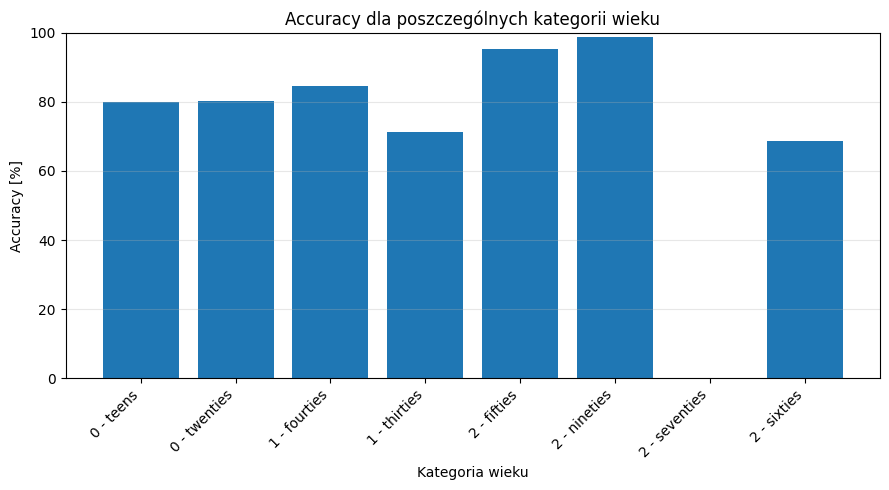

Confusion matrix — liczba próbek:


Klasa przewidziana,0,1,2
Klasa prawdziwa,,,
0,369,67,24
1,102,344,14
2,9,11,440


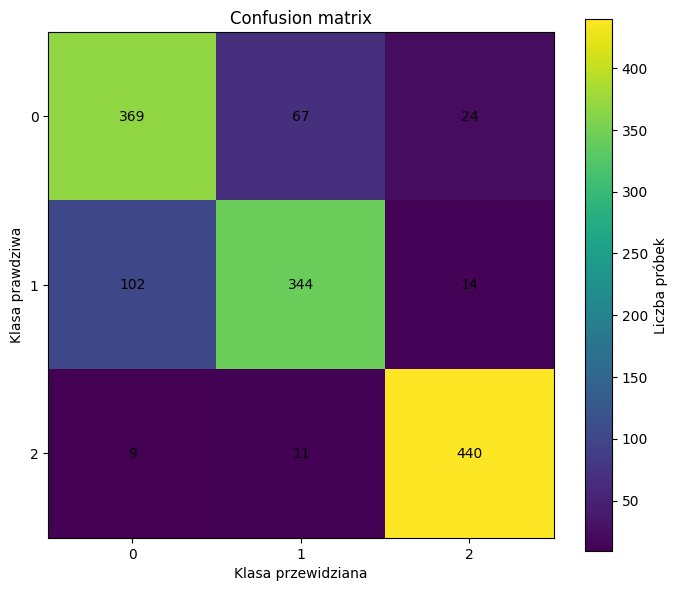

Confusion matrix — procentowo w ramach klasy prawdziwej:


Klasa przewidziana,0,1,2
Klasa prawdziwa,,,
0,80.22,14.57,5.22
1,22.17,74.78,3.04
2,1.96,2.39,95.65


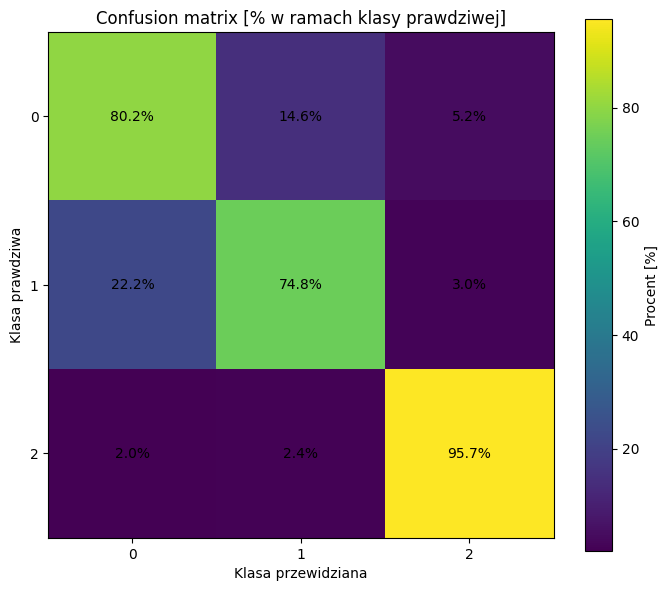

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_CSV = "test_predictions_balanced.csv"

results_df = pd.read_csv(RESULTS_CSV)

# =========================
# ACCURACY DLA KATEGORII
# =========================
per_class = (
    results_df
    .groupby(["true_class", "true_age"], dropna=False)["correct"]
    .agg(samples="count", accuracy="mean")
    .reset_index()
)
per_class["accuracy_percent"] = per_class["accuracy"] * 100
per_class["label"] = per_class.apply(
    lambda row: f"{int(row['true_class'])} - {row['true_age']}",
    axis=1
)

print("Accuracy dla poszczególnych kategorii:")
display(per_class[["true_class", "true_age", "samples", "accuracy_percent"]])

plt.figure(figsize=(9, 5))
plt.bar(per_class["label"], per_class["accuracy_percent"])
plt.ylim(0, 100)
plt.xlabel("Kategoria wieku")
plt.ylabel("Accuracy [%]")
plt.title("Accuracy dla poszczególnych kategorii wieku")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# =========================
# CONFUSION MATRIX
# =========================
labels = sorted(set(results_df["true_class"]).union(set(results_df["predicted_class"])))

cm = pd.crosstab(
    results_df["true_class"],
    results_df["predicted_class"],
    rownames=["Klasa prawdziwa"],
    colnames=["Klasa przewidziana"],
    dropna=False
)
cm = cm.reindex(index=labels, columns=labels, fill_value=0)

print("Confusion matrix — liczba próbek:")
display(cm)

plt.figure(figsize=(7, 6))
plt.imshow(cm.values)
plt.title("Confusion matrix")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa prawdziwa")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)
plt.colorbar(label="Liczba próbek")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm.values[i, j]), ha="center", va="center")

plt.tight_layout()
plt.show()

# =========================
# CONFUSION MATRIX W PROCENTACH
# =========================
cm_percent = cm.div(cm.sum(axis=1).replace(0, np.nan), axis=0) * 100

print("Confusion matrix — procentowo w ramach klasy prawdziwej:")
display(cm_percent.round(2))

plt.figure(figsize=(7, 6))
plt.imshow(cm_percent.values)
plt.title("Confusion matrix [% w ramach klasy prawdziwej]")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa prawdziwa")
plt.xticks(np.arange(len(labels)), labels)
plt.yticks(np.arange(len(labels)), labels)
plt.colorbar(label="Procent [%]")

for i in range(cm_percent.shape[0]):
    for j in range(cm_percent.shape[1]):
        value = cm_percent.values[i, j]
        text = "" if np.isnan(value) else f"{value:.1f}%"
        plt.text(j, i, text, ha="center", va="center")

plt.tight_layout()
plt.show()
